In [28]:
import math
import numpy as np
import torch
import matplotlib.pyplot as plt
from scipy.stats import norm

from continuous_states import (
    build_1d_grid,
    build_1d_transition_matrix,
    build_1d_initial_prob,
    build_1d_emission_loglike,
    build_1d_emission_loglike_partial,
    build_resource_values,
    build_resource_budget_tensors_simplified,
    viterbi_torch_resource_budget_simplified,
    viterbi_torch_unconstrained,
    recover_cumulative_resource_path,
    simulate_1d_ssm_budget_constrained_truncated
)

In [150]:
# Example notebook execution block with:
# - constrained ground-truth simulation
# - emissions only at selected timepoints
# - constrained and unconstrained decoding

T = 72
hidden_coeff = 0.9
hidden_std = 1
hidden_var = hidden_std**2

init_var = hidden_var / (1 - hidden_coeff**2)


emission_coeff = 1
emission_std = .5 #2*init_var
emission_var = emission_std**2

xmin, xmax = -3.0 * init_var, 3.0 * init_var

K = 201

x_edges, x_centers = build_1d_grid(xmin, xmax, K)
P = build_1d_transition_matrix(x_centers, x_edges, hidden_coeff, hidden_var)
pi = build_1d_initial_prob(x_edges, mean0=0.0, var0=init_var)

resource_limit = 3
resource_values = build_resource_values(x_centers, resource_limit)

# Time-varying cumulative-resource budget
tgrid = np.arange(T)
period = 24
budget_center_amplitude = 4.0
budget_half_width = 2.0

budget_center = -budget_center_amplitude * np.cos(2 * np.pi * tgrid / period) + 6
lower_bounds = np.floor(budget_center - budget_half_width).astype(int).clip(0)
upper_bounds = np.ceil(budget_center + budget_half_width).astype(int)

print(f'The grid bounds are {xmin} and {xmax}. The stationary variance is {init_var}\n Grid resolution is {(xmax - xmin)/K}')

The grid bounds are -15.789473684210531 and 15.789473684210531. The stationary variance is 5.263157894736843
 Grid resolution is 0.15710919088766698


In [154]:
# Simulate ground truth over all times
rng_seed = np.random.default_rng(67)


x_true, y_full, resource_true, cum_resource_true = simulate_1d_ssm_budget_constrained_truncated(
    T=T,
    a=hidden_coeff,
    q=hidden_var,
    b=emission_coeff,
    r=emission_var,
    lower_bounds=lower_bounds,
    upper_bounds=upper_bounds,
    resource_limit=resource_limit,
    x0=0.0,
    seed=rng_seed,
)

# Keep emissions only at selected times, 
# obs_times = np.arange(0, T, 1)
# num_obs = 36
# obs_times = np.sort(np.random.choice(np.arange(0, T), size=num_obs, replace=False))
obs_times = np.where(rng_seed.random(T) < 1/10)[0]

obs_values = y_full[obs_times]

# Build sparse emission log-likelihoods
emit_loglik = build_1d_emission_loglike_partial(
    T=T,
    centers=x_centers,
    b=emission_coeff,
    r=emission_var,
    obs_times=obs_times,
    obs_values=obs_values,
)

# Constrained decode
cst = build_resource_budget_tensors_simplified(
    resource_values=resource_values,
    lower_bounds=lower_bounds,
    upper_bounds=upper_bounds,
)

hidden_path_constrained, resource_state_path_constrained = viterbi_torch_resource_budget_simplified(
    init_prob=pi,
    trans_mat=P,
    emit_loglik=emit_loglik,
    cst=cst,
    apply_eval_every_t=False,
    device="cpu",
    debug=False,
)

x_hat_constrained = x_centers[hidden_path_constrained]
cum_resource_hat_constrained = recover_cumulative_resource_path(
    resource_state_path_constrained,
    lower_bounds=cst["low"],
    fail_index=cst["fail_index"],
)

# Unconstrained decode
hidden_path_unconstrained = viterbi_torch_unconstrained(
    init_prob=pi,
    trans_mat=P,
    emit_loglik=emit_loglik,
    device="cpu",
    debug=False,
)

x_hat_unconstrained = x_centers[hidden_path_unconstrained]
resource_hat_unconstrained = np.array(
    [resource_values[k] for k in hidden_path_unconstrained],
    dtype=int,
)
cum_resource_hat_unconstrained = np.cumsum(resource_hat_unconstrained)

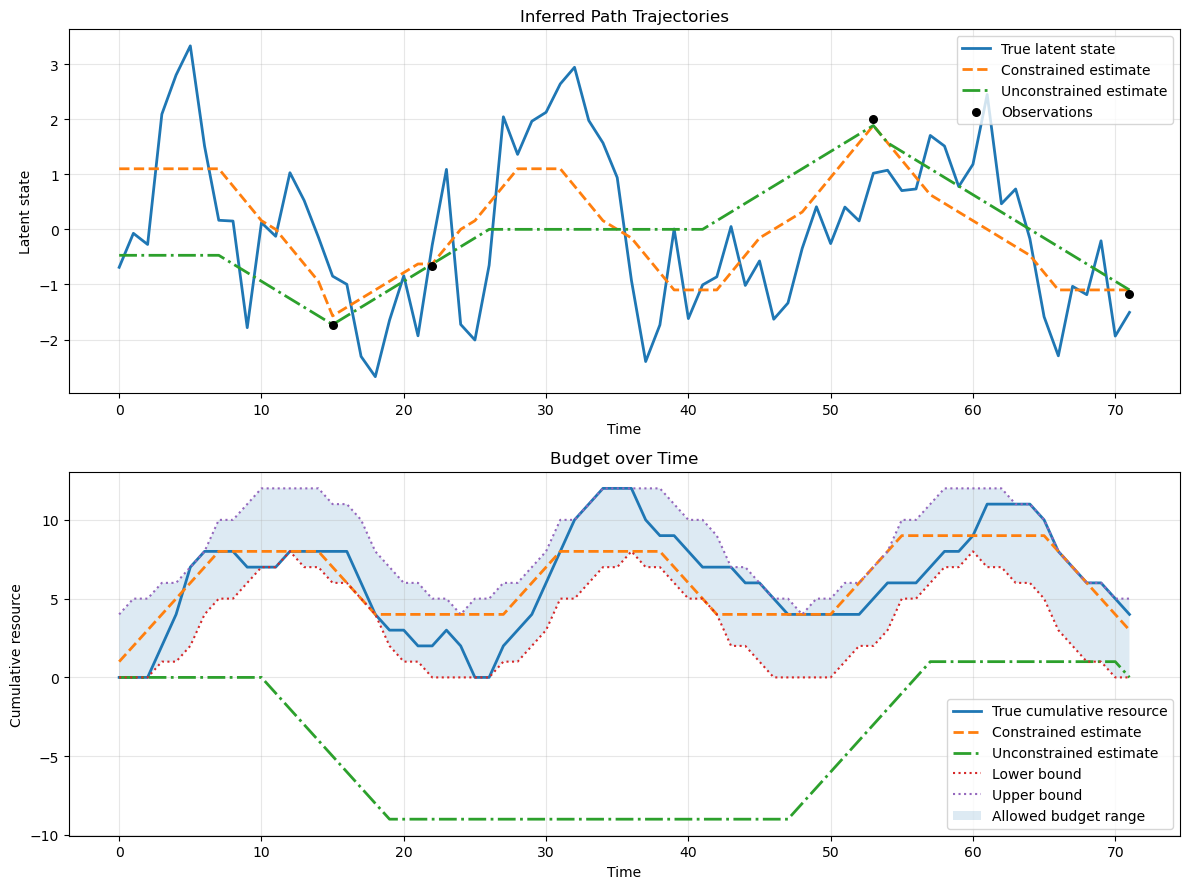

In [159]:
# Stacked plots:
# Top: true vs constrained vs unconstrained latent state, plus observations
# Bottom: true vs constrained vs unconstrained cumulative resource, with bounds

fig, axes = plt.subplots(2, 1, figsize=(12, 9), sharex=True)

# Top plot: latent states
axes[0].plot(tgrid, x_true, label="True latent state", linewidth=2)
axes[0].plot(tgrid, x_hat_constrained, label="Constrained estimate", linewidth=2, linestyle="--")
axes[0].plot(tgrid, x_hat_unconstrained, label="Unconstrained estimate", linewidth=2, linestyle="-.")
axes[0].scatter(obs_times, obs_values, label="Observations", color="black", s=30, zorder=4)

axes[0].set_xlabel("Time")
axes[0].tick_params(axis="x", labelbottom=True)
axes[0].set_ylabel("Latent state")
axes[0].set_title("Inferred Path Trajectories")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Bottom plot: cumulative resource
axes[1].plot(tgrid, cum_resource_true, label="True cumulative resource", linewidth=2)
axes[1].plot(tgrid, cum_resource_hat_constrained, label="Constrained estimate", linewidth=2, linestyle="--")
axes[1].plot(tgrid, cum_resource_hat_unconstrained, label="Unconstrained estimate", linewidth=2, linestyle="-.")
axes[1].plot(tgrid, lower_bounds, label="Lower bound", linewidth=1.5, linestyle=":")
axes[1].plot(tgrid, upper_bounds, label="Upper bound", linewidth=1.5, linestyle=":")
axes[1].fill_between(tgrid, lower_bounds, upper_bounds, alpha=0.15, label="Allowed budget range")

axes[1].set_xlabel("Time")
axes[1].set_ylabel("Cumulative resource")
axes[1].set_title("Budget over Time")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("latent_and_budget_paths.pdf", bbox_inches="tight")
plt.show()

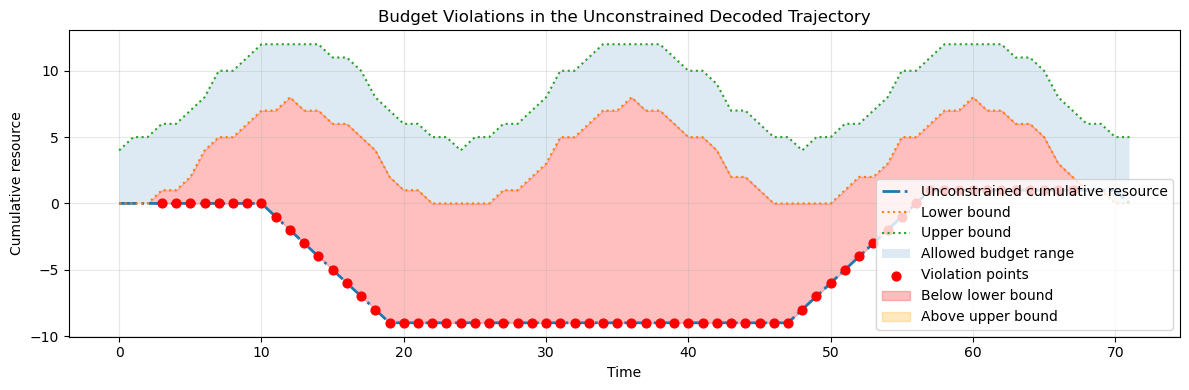

In [157]:
# Third plot: highlight where the unconstrained decoded cumulative resource
# violates the time-varying budget bounds

fig, ax = plt.subplots(figsize=(12, 4))

viol_low = cum_resource_hat_unconstrained < lower_bounds
viol_high = cum_resource_hat_unconstrained > upper_bounds
viol_any = viol_low | viol_high

ax.plot(tgrid, cum_resource_hat_unconstrained, label="Unconstrained cumulative resource", linewidth=2, linestyle="-.")
ax.plot(tgrid, lower_bounds, label="Lower bound", linewidth=1.5, linestyle=":")
ax.plot(tgrid, upper_bounds, label="Upper bound", linewidth=1.5, linestyle=":")
ax.fill_between(tgrid, lower_bounds, upper_bounds, alpha=0.15, label="Allowed budget range")

# Mark violating time points
ax.scatter(
    tgrid[viol_any],
    cum_resource_hat_unconstrained[viol_any],
    color="red",
    s=40,
    label="Violation points",
    zorder=3,
)

# Shade violating regions
ax.fill_between(
    tgrid,
    lower_bounds,
    cum_resource_hat_unconstrained,
    where=viol_low,
    color="red",
    alpha=0.25,
    interpolate=True,
    label="Below lower bound",
)

ax.fill_between(
    tgrid,
    upper_bounds,
    cum_resource_hat_unconstrained,
    where=viol_high,
    color="orange",
    alpha=0.25,
    interpolate=True,
    label="Above upper bound",
)

ax.set_xlabel("Time")
ax.set_ylabel("Cumulative resource")
ax.set_title("Budget Violations in the Unconstrained Decoded Trajectory")
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("unconstrained_budget_violations.pdf", bbox_inches="tight")
plt.show()